In [ ]:
import pulp
from dataclasses import dataclass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime.date

In [126]:
@dataclass
class BatterySpecs:
    capacity: float     # capacity in MWh
    max_power: float    # max power in MW
    efficiency: float   # assume charge/discharge efficiency is the same
    SOC_min: float      # min charge in MWh
    SOC_max: float      # max charge in MWh
    dt: float           # time in hours that a dispatch is for (1/12 for NEM 5 minute dispatch)

@dataclass
class BESS:
    specs: BatterySpecs

    SOC_curr: float     # current SOC of the battery
    PnL: float          # PnL of the asset

    # charging or discharging
    def charge(self, power: float, price: float):
        energy = power * self.specs.dt      # total energy exchanged in this period
        self.SOC_curr += energy * self.specs.efficiency
        self.PnL -= energy * price
    def discharge(self, power: float, price: float):
        energy = power * self.specs.dt
        self.SOC_curr -= energy / self.specs.efficiency
        self.PnL += energy * price
    
    def dispatch(self, forecast, price: float):
        result = solve_dispatch_problem(self, forecast)
        charge = result["charge"][0]        # find the next recommended decision (charge/discharge) according to the forecast
        discharge = result["discharge"][0]
        self.charge(charge, price)          # carry out the dispatch, receiving the realised price
        self.discharge(discharge, price)


def solve_dispatch_problem(asset, prices):
    specs = asset.specs
    max_power = specs.max_power
    efficiency = specs.efficiency
    SOC_min = specs.SOC_min
    SOC_max = specs.SOC_max
    dt = specs.dt
    
    SOC_curr = asset.SOC_curr

    T = len(prices)
    periods = range(T)

    problem = pulp.LpProblem("battery_dispatch", pulp.LpMaximize)

    charge = [pulp.LpVariable(f'charge_{t}', 0, max_power) for t in periods]
    discharge = [pulp.LpVariable(f'discharge_{t}', 0, max_power) for t in periods]

    SOC = [pulp.LpVariable(f'SOC_{t}', SOC_min, SOC_max) for t in range(T+1)]

    problem += pulp.lpSum(
        prices[t]*(discharge[t] - charge[t])*dt for t in periods
    )

    problem += SOC[0] == SOC_curr

    for t in periods:
        problem += SOC[t+1] == SOC[t] + (
            efficiency*charge[t] - discharge[t]/efficiency
        )*dt

    problem.solve()

    p_c = np.array([pulp.value(charge[t]) for t in periods])
    p_d = np.array([pulp.value(discharge[t]) for t in periods])
    soc = np.array([pulp.value(SOC[t]) for t in range(T+1)])

    return {"charge": p_c,
            "discharge": p_d, 
            "SOC": soc}

def simulate_trading_rolling(data: pd.DataFrame, specs: BatterySpecs, windowsize: int):
    '''
    simulates trading with perfect foresight on a small window
    rolling optimisation
    '''
    asset = BESS(specs, specs.capacity/2, 0) # start at 50% full BESS
    prices = np.array(data["RRP"].to_list())
    times = np.array(data["SETTLEMENTDATE"].to_list())
    PnL_out = []
    SOC_out = []
    times_out = []
    i=0
    # repeat until our window goes outside of our testing period
    while i+windowsize<=prices.size:
        #print(f"optimising at t={i}")
        forecast = prices[i:i+windowsize]
        asset.dispatch(forecast, prices[i])
        PnL_out.append(asset.PnL)
        SOC_out.append(asset.SOC_curr)
        times_out.append(times[i])
        i+=1
    return pd.DataFrame({"time":times_out, "PnL":PnL_out, "SOC": SOC_out})
    

In [ ]:
# plausible values for a medium-large scale BESS
specs = BatterySpecs(
    capacity=100,
    max_power=100,
    efficiency=0.92,
    SOC_min=10,
    SOC_max=90,
    dt=1/12,
)



In [111]:
data = pd.read_csv("price_data.csv")[["SETTLEMENTDATE", "RRP"]]
data["SETTLEMENTDATE"] = pd.to_datetime(data["SETTLEMENTDATE"])

In [125]:
results = simulate_trading_rolling(data, specs, windowsize=288)

KeyboardInterrupt: 

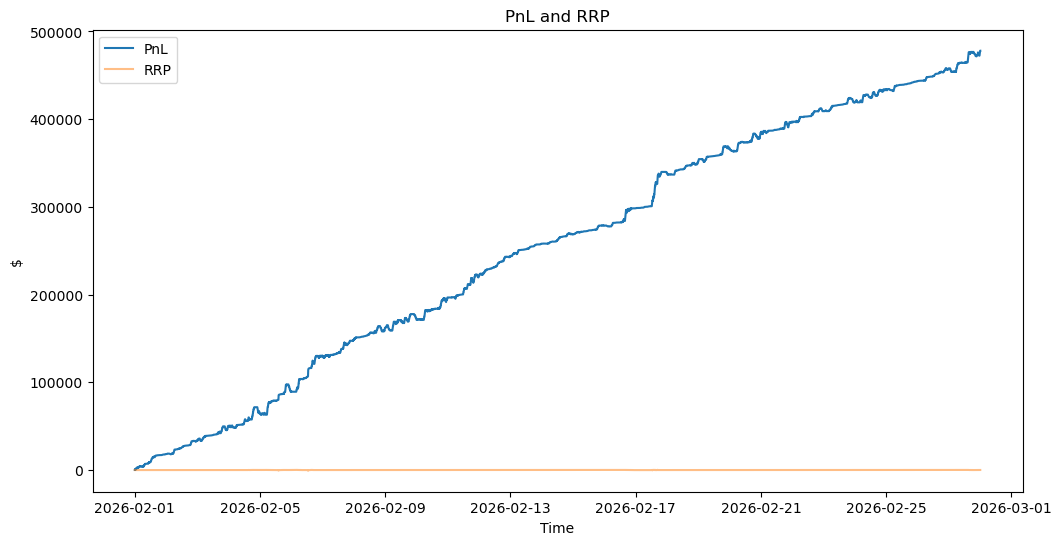

In [121]:
plt.figure(figsize=(12,6))

# PnL (left axis)
plt.plot(results["time"], results["PnL"], label="PnL")

rrp_aligned = data.set_index("SETTLEMENTDATE").loc[results["time"], "RRP"]

plt.plot(results["time"], rrp_aligned, label="RRP", alpha=0.5)

plt.legend()
plt.xlabel("Time")
plt.ylabel("$")
plt.title("PnL and RRP")

plt.show()